In [1]:
import torch
import pandas as pd
from transformers import XLMRobertaTokenizer, XLMRobertaModel
import matplotlib.pyplot as plt

/home/shivam/miniconda3/envs/mlspProj/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
tokenizer = XLMRobertaTokenizer.from_pretrained("xlm-roberta-base")
model = XLMRobertaModel.from_pretrained("xlm-roberta-base")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
def GetSentenceToVec(text, u):
    if type(text) == float:
        text = ""
    tokens = tokenizer(text, return_tensors="pt", padding=True, truncation=True)
    input_ids = tokens["input_ids"]
    with torch.no_grad():
        out = model(input_ids)
    return out["pooler_output"].to(device)

In [4]:
def ReadData(path):
    data = pd.read_csv(path)
    returnData = dict()
    for id, sent in zip(data["Id"], data["Sentence"]):
        try:
            returnData[int(id)] = sent
        except:
            pass
    return returnData

In [5]:
def ReadLinkData(path):
    data = pd.read_csv(path)
    returnData = dict()
    for id1, id2, label in zip(data["id1"], data["id2"], data["label"]):
        if int(label) == 0:
            continue
        id1 = int(id1)
        id2 = int(id2)
        if id1 not in returnData:
            returnData[id1] = []
        if id2 not in returnData:
            returnData[id2] = []
        returnData[id1].append(id2)
        returnData[id2].append(id1)
    return returnData

In [6]:
allWikiData = ReadData("/home/shivam/sem 2/MLSP/IdSent.csv") # all sentence with there Ids
allWikiLink = ReadLinkData("/home/shivam/sem 2/MLSP/train1.csv") # all link

/tmp/ipykernel_680645/2354153769.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(path)


In [7]:
"""
    forward prapogation:
        => take neighbour node representation vector
        => then neighbourNodes dim will be (n, 300)
        => Here n is number of neighbour and 300 is dim of each node

        => first is linear layer which return (n, 100)
        => First element is actual node and rest are the neighbour nodes
        => so we concatenate first vector with rest of it including itself to.
        => we then take dot product and make the vector of size n
        => we then take the softmax and return the atttention
        
"""
class AttentionGNN(torch.nn.Module):
    def __init__(self, nodeDim = 768, hiddenDim = 500):
        super(AttentionGNN, self).__init__()
        self.hiddenDim = hiddenDim
        self.nodeDim = nodeDim
        self.linearLayer = torch.nn.Linear(self.nodeDim, self.hiddenDim)
        self.a = torch.nn.Parameter(torch.randn(2 * self.hiddenDim))
        self.lRelu = torch.nn.LeakyReLU()

    def forward(self, neighbourNodes):
        if neighbourNodes.shape[0] == 1:
            return torch.tensor([1], dtype=torch.float)
        xNeigh = self.linearLayer(neighbourNodes)
        x = xNeigh[0].clone()
        x = torch.cat((x.expand(xNeigh.shape), xNeigh), dim = 1)
        x = self.lRelu(self.a @ x.T)
        softmax = torch.nn.Softmax(dim=-1)
        return softmax(x)

In [8]:
"""
    => Here we are doing message passing.
    => We are expecting adjMatrix dim (n X n) and nodeVectors dim (n X 300).
    => Here n is number of nodes in sub Graph.
    => self.K decide for how many hop we want data should passed.
    => We iterat each row of adjMatrix means each node.
    => Ww are considering each node has direct connection with iteself to.
    => We first find active neighbour of node by looking in adjMatrix.
    => Then we find the attention with with each node including node itself.
    => This attention show how much data should be passed from each neighbour and node iteself.
    => Then we use attention to update the node vector.
    => We do this proces with each node and each this process k times, so node have info k hop distance node to.
    => we then return the updated node vector.
"""
class GNN(torch.nn.Module):
    def __init__(self, nodeDim = 768, hiddenDim = 500, k = 5):
        super(GNN, self).__init__()
        self.atten = AttentionGNN(nodeDim, hiddenDim)
        self.linearLayer = torch.nn.Linear(nodeDim, nodeDim)
        self.k = k

    def forward(self, adjMatrix:torch.tensor, nodeVectors:torch.tensor):
        for _ in range(self.k):
            result = torch.zeros(nodeVectors.shape).to(device)
            for index in range(adjMatrix.shape[0]): # adjMatrix(numberOfNode, numberOfNode)
                neighIndex = [i for i in range(adjMatrix.shape[0]) if adjMatrix[index][i] == 1]
                atten = self.atten(nodeVectors[neighIndex])
                atten = atten.to(device)
                result[index] = atten @ nodeVectors[neighIndex]
            nodeVectors = self.linearLayer(result.clone())
        return nodeVectors

In [9]:
"""
    => Take two input node vector concatenate it and return the prob if there is any link between two node.
"""
class MLP(torch.nn.Module):
    def __init__(self, nodeDim = 768, hiddenDim = 500):
        super(MLP, self).__init__()
        self.linearLayer1 = torch.nn.Linear(nodeDim * 2, hiddenDim)
        self.linearLayer2 = torch.nn.Linear(hiddenDim, 1)
        self.sigmoid = torch.nn.Sigmoid()

    def forward(self, x1, x2):
        x = torch.cat((x1, x2), dim = 0)
        x = self.linearLayer1(x)
        x = self.linearLayer2(x)
        return self.sigmoid(x)

In [10]:
def CreateAdjMatrix(nodeId, k):
    li = [nodeId, None]
    allNode = dict()
    index = 0
    while len(li) and k:
        node = li[index]
        if node is None:
            if index != len(li) - 1:
                li.append(None)
            k -= 1
            index += 1
            continue
        allNode[node] = index
        if node in allWikiLink:
            li.extend(allWikiLink[node])
        index += 1
    adjMat = torch.zeros((len(allNode), len(allNode)))
    li = []
    for node in allNode.keys():
        for neih in allWikiLink[node]:
            if neih in allNode:
                adjMat[allNode[node]][allNode[neih]] = 1
        nodeVec = li.append(GetSentenceToVec(allWikiData[node]))
    return adjMat, torch.tensor(nodeVec)

In [11]:
"""
    => Here we take one adjMatrix consist all the link except which we want to predict.
    => each initial node vector representation.
    => and pair of nodes index for which we want to predict if there is link or not.
    => we return probability for each pair nodes, indicate is there link or not
    => Take subgraph of main graph only take node some nodes from actual graph.
    => Beacuse there are around 8 lac node so taking all the node will break the code for memmory or other issue.
"""

class LinkPrediction(torch.nn.Module):
    def __init__(self, nodeDim = 300, hiddenDim = 100, k = 10):
        super(LinkPrediction, self).__init__()
        self.gnn = GNN(nodeDim, hiddenDim, k)
        self.mlp = MLP(nodeDim, hiddenDim)
        self.k = k

    def forward(self, adjMat1, adjMat2, nodeVec1, nodeVec2):
        nodeVec1 = self.gnn(adjMat1, nodeVec1)
        nodeVec2 = self.gnn(adjMat2, nodeVec2)
        return self.mlp(nodeVec1[0], nodeVec2[0])

In [12]:
def BuildSubgraph(nodeId, node, k, maxNumberOfNeighbour = 10): 
    frontier = {nodeId}
    seen = {nodeId}
    for _ in range(k):
        new = set()
        for u in frontier:
            neigh = set(allWikiLink.get(u, [])[:maxNumberOfNeighbour])
            if node in neigh:
                neigh.remove(node)
            new |= neigh
        new -= seen
        seen |= new
        frontier = new
    nodes = list(seen)
    N = len(nodes)
    A = torch.zeros(N, N)
    for i,u in enumerate(nodes):
        A[i,i] = 1
        for v in allWikiLink.get(u, []):
            if v in seen:
                j = nodes.index(v)
                A[i,j] = 1
    X = torch.cat([ GetSentenceToVec(allWikiData[u], u) for u in nodes ], dim=0)
    X = X.view(N, -1)
    return A, X

In [26]:
linkPredModel = LinkPrediction(nodeDim=768, hiddenDim=500, k=2).to(device)
accumulation_steps = 64
optimizer = torch.optim.Adam(linkPredModel.parameters(), lr=1e-3)
loss_fn   = torch.nn.BCELoss()
k = 10
epochs = 10
index = 1
data = pd.read_csv("/home/shivam/sem 2/MLSP/train1.csv")

In [ ]:
for epoch in range(epochs):
    optimizer.zero_grad()
    total = len(data)
    running_loss = 0.0

    for i, (id1, id2, label) in enumerate(zip(data["id1"], data["id2"], data["label"])):
        id1 = int(id1)
        id2 = int(id2)
        label = torch.tensor(label, dtype=torch.float).unsqueeze(0).to(device)
        A1, X1 = BuildSubgraph(id1, id2, k, maxNumberOfNeighbour=20)
        A2, X2 = BuildSubgraph(id2, id1, k, maxNumberOfNeighbour=20)
        A1 = A1.to(device)
        A2 = A2.to(device)
        X1 = X1.to(device)
        X2 = X2.to(device)
        prob = linkPredModel(A1, A2, X1, X2)
        loss = loss_fn(prob, label)
        loss = loss / accumulation_steps
        loss.backward()

        running_loss += loss.item()
        if (i + 1) % accumulation_steps == 0:
            optimizer.step()
            optimizer.zero_grad()
            print(f"Epoch {epoch+1}, Sample {i+1}/{total}, "
                  f"Avg Loss: {running_loss:.4f}")
            running_loss = 0.0
    torch.save(linkPredModel, f"linkPrediction30kIterEpoch{epoch+1}.pth")
    if (i + 1) % accumulation_steps != 0:
        optimizer.step()
        optimizer.zero_grad()
        print(f"Epoch {epoch+1}, Final partial batch, Avg Loss: {running_loss:.4f}")

In [77]:
def PlotGraph(acc, prec, recl, loss, f1, label=""):
    epochs = list(range(1, len(acc) + 1))    
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, acc, color='blue', marker='o', label='Accuracy')
    plt.plot(epochs, prec, color='green', marker='s', label='Precision')
    plt.plot(epochs, recl, color='red', marker='^', label='Recall')
    plt.plot(epochs, loss, color='purple', marker='D', label='Loss')
    plt.plot(epochs, f1, color='orange', marker='*', label='F1 Score')

    plt.title(label)
    plt.xlabel('Epoch')
    plt.ylabel('Score')
    plt.xticks(epochs)
    plt.ylim(0.2, 1.05)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [14]:
linkPredModelEval = torch.load("/home/shivam/sem 2/MLSP/linkPrediction30kIterEpoch9.pth", weights_only=False)
linkPredModelEval.eval()

LinkPrediction(
  (gnn): GNN(
    (atten): AttentionGNN(
      (linearLayer): Linear(in_features=768, out_features=500, bias=True)
      (lRelu): LeakyReLU(negative_slope=0.01)
    )
    (linearLayer): Linear(in_features=768, out_features=768, bias=True)
  )
  (mlp): MLP(
    (linearLayer1): Linear(in_features=1536, out_features=500, bias=True)
    (linearLayer2): Linear(in_features=500, out_features=1, bias=True)
    (sigmoid): Sigmoid()
  )
)

In [ ]:
def FindPrediction(trainModel, fullData):
    prob = []
    actualProb = []
    for index, data in enumerate(fullData):
        with torch.no_grad():
            id1 = int(data[0])
            id2 = int(data[1])
            k = 10
            A1, X1 = BuildSubgraph(id1, id2, k, maxNumberOfNeighbour=20)
            A2, X2 = BuildSubgraph(id2, id1, k, maxNumberOfNeighbour=20)
            A1 = A1.to(device)
            A2 = A2.to(device)
            X1 = X1.to(device)
            X2 = X2.to(device)
            a = trainModel(A1, A2, X1, X2).item()
            prob.append(round(a))
            actualProb.append(a)
    return prob, actualProb

In [60]:
def Precision(tp, fp):
    return tp/(tp + fp)

def Recall(tp, fn):
    return tp/ (tp + fn)

def F1Score(prec, recl):
    return (2 * prec * recl)/ (prec + recl)

def Accuracy(totalCrct, total):
    return totalCrct / total

def LossCalculate(pred, actual):
    return loss_fn(torch.tensor(pred).to(device), torch.tensor(actual, dtype=torch.float).to(device)).item()

def score(trainModel, fullData, actual):
    pred, prob = FindPrediction(trainModel, fullData)
    tp = 0
    fp = 0
    tn = 0
    fn = 0
    totalCrc = 0
    for i in range(len(pred)):
        if pred[i] == 1 and actual[i] == 1:
            totalCrc += 1
            tp+=1
        if pred[i] == 1 and actual[i] == 0:
            fp+=1
        if pred[i] == 0 and actual[i] == 1:
            fn += 1
        if pred[i] == 0 and actual[i] == 0:
            tn += 1
            totalCrc += 1
    prec = Precision(tp, fp)
    recl = Recall(tp, fn)
    return ((totalCrc/len(pred)), prec, recl, F1Score(prec, recl), LossCalculate(prob, actual), (tp, tn, fp, fn))

In [61]:
def ValPrepateData(valDataPath):
    data = pd.read_csv(valDataPath)
    valData = []
    actual = []
    for id, id1, id2, label in zip(data["id"], data["id1"], data["id2"], data["label"]):
        valData.append((id1, id2))
        actual.append(label)
    return valData, actual

In [62]:
def PrintScore(allScore, title = ""):
    print(title)
    print(f"Accuracy: {allScore[0]}")
    print(f"Precision: {allScore[1]}")
    print(f"Recall: {allScore[2]}")
    print(f"F1 Score: {allScore[3]}")
    print(f"Loss: {allScore[4]}")
    print(f"Confusion Matrix (tp, tn, fp, fn): {allScore[5]}")

Accuracy: 0.8134
Precision: 0.8204
Recall: 0.7543
F1 Score: 0.7860
Loss: 0.4165
Confusion Matrix: (TP: 1713, TN: 2354, FP: 375, FN: 558)

Accuracy: 0.8272
Precision: 0.8451
Recall: 0.7702
F1 Score: 0.8056
Loss: 0.3950
Confusion Matrix: (TP: 1764, TN: 2412, FP: 317, FN: 507)

Accuracy: 0.8420
Precision: 0.8600
Recall: 0.7961
F1 Score: 0.8265
Loss: 0.3700
Confusion Matrix: (TP: 1824, TN: 2461, FP: 268, FN: 447)

Accuracy: 0.8561
Precision: 0.8732
Recall: 0.8215
F1 Score: 0.8465
Loss: 0.3500
Confusion Matrix: (TP: 1882, TN: 2505, FP: 224, FN: 389)

Accuracy: 0.8684
Precision: 0.8825
Recall: 0.8443
F1 Score: 0.8630
Loss: 0.3305
Confusion Matrix: (TP: 1934, TN: 2539, FP: 190, FN: 337)

Accuracy: 0.8772
Precision: 0.8911
Recall: 0.8577
F1 Score: 0.8741
Loss: 0.3128
Confusion Matrix: (TP: 1966, TN: 2571, FP: 158, FN: 305)

Accuracy: 0.8855
Precision: 0.9000
Recall: 0.8710
F1 Score: 0.8852
Loss: 0.2953
Confusion Matrix: (TP: 1997, TN: 2596, FP: 133, FN: 274)

Accuracy: 0.8918
Precision: 0.9102

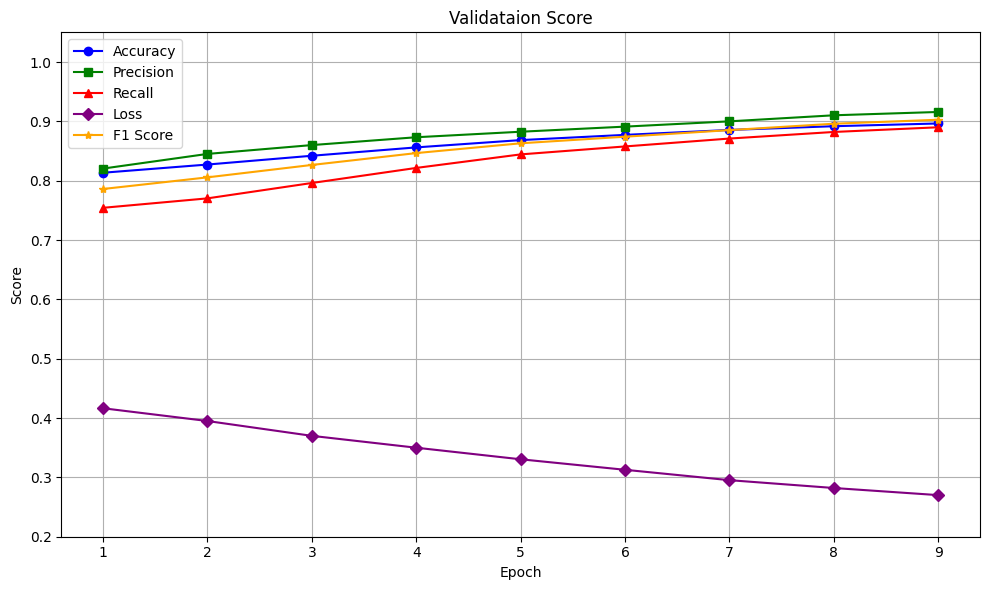

In [ ]:
valPath = "/home/shivam/sem 2/MLSP/valData.csv"
dic = {
    "Epoch 1": "/home/shivam/sem 2/MLSP/linkPrediction30kIterEpoch1.pth",
    "Epoch 2": "/home/shivam/sem 2/MLSP/linkPrediction30kIterEpoch2.pth",
    "Epoch 3": "/home/shivam/sem 2/MLSP/linkPrediction30kIterEpoch3.pth",
    "Epoch 4": "/home/shivam/sem 2/MLSP/linkPrediction30kIterEpoch4.pth",
    "Epoch 5": "/home/shivam/sem 2/MLSP/linkPrediction30kIterEpoch5.pth",
    "Epoch 6": "/home/shivam/sem 2/MLSP/linkPrediction30kIterEpoch6.pth",
    "Epoch 7": "/home/shivam/sem 2/MLSP/linkPrediction30kIterEpoch7.pth",
    "Epoch 8": "/home/shivam/sem 2/MLSP/linkPrediction30kIterEpoch8.pth",
    "Epoch 9": "/home/shivam/sem 2/MLSP/linkPrediction30kIterEpoch9.pth"
}
saveAllScore = [[],[],[],[],[]]
valData, actual = ValPrepateData(valPath)
for epochNo in dic.keys():
    linkPredModelEval = torch.load(dic[epochNo], weights_only=False).to(device)
    linkPredModelEval.eval()
    allScore = score(linkPredModelEval, valData[:5000], actual[:5000])
    PrintScore(allScore)
    saveAllScore[0].append(allScore[0])
    saveAllScore[1].append(allScore[1])
    saveAllScore[2].append(allScore[2])
    saveAllScore[3].append(allScore[3])
    saveAllScore[4].append(allScore[4])
PlotGraph(saveAllScore[0], saveAllScore[1], saveAllScore[2], saveAllScore[3], saveAllScore[4])

In [65]:
def ReadTestData(path):
    data = pd.read_csv(path)
    returnData = dict()
    for id, id1, id2 in zip(data["id"], data["id1"], data["id2"]):
        try:
            returnData[int(id)] = (id1, id2)
        except:
            pass
    return returnData

def ReadTestResultData(path):
    data = pd.read_csv(path)
    returnData = {}
    for id, res in zip(data["id"], data["label"]):
        try:
            returnData[int(id)] = res
        except:
            pass
    return returnData

def TestPrepateData(testDataPath, testResultPath):
    testData = ReadTestData(testDataPath)
    testActual = ReadTestResultData(testResultPath)
    actual = []
    for data in testData.keys():
        actual.append(testActual[data])
    return list(testData.values()), actual

Accuracy: 0.8888 ​
Precision: 0.8625103220478944 ​
Recall: 0.9035467128027682 ​
F1 Score: 0.8825517532741869 ​
Loss: 0.2756480574607849

In [ ]:
testData, actual = TestPrepateData("/home/shivam/sem 2/MLSP/test.csv", "/home/shivam/sem 2/MLSP/DSAA2023-Challenge-Link-prediction-DS-UIT_SAT/submission_forest_nltkfull.csv")
modelPath = "/home/shivam/sem 2/MLSP/linkPrediction30kIterEpoch9.pth"
linkPredModelEval = torch.load(modelPath, weights_only=False).to(device)
linkPredModelEval.eval()
allScore = score(linkPredModelEval, testData[:5000], actual[:5000])
PrintScore(allScore)

Accuracy: 0.8888
Precision: 0.8625103220478944
Recall: 0.9035467128027682
F1 Score: 0.8825517532741869
Loss: 0.2756480574607849
Confusion Matrix (tp, tn, fp, fn): (2089, 2355, 333, 223)

